# Method results

Per-method report card. Pick one `METHOD` in the first cell; everything below runs for that method only.

Sections:
1. Simulation results
2. Classifier results
3. Stability diagnostics from resampling
4. Final protein list + enrichment

In [54]:
METHOD = "ttest"   # change this to switch the whole notebook

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.styles.colors import CATEGORICAL, PALETTE, SEQUENTIAL_TEAL, SEQUENTIAL_ORANGE

sns.set_theme(style="whitegrid", context="notebook")

RESULTS = REPO_ROOT / "results"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"

STAGE_DIRS = {
    "simulation": RESULTS / "simulation" / METHOD,
    "classifier": RESULTS / "classifier" / METHOD,
    "selection":  RESULTS / "selection" / METHOD,
    "enrichment": RESULTS / "enrichment" / METHOD,
}
missing = [s for s, p in STAGE_DIRS.items() if not p.exists()]
assert not missing, f"Missing result directories for METHOD={METHOD!r}: {missing}"

def load_meta(path: Path) -> dict:
    with open(path) as f:
        return json.load(f)

print(f"METHOD = {METHOD}")
for stage, path in STAGE_DIRS.items():
    print(f"  {stage:<10s} -> {path.relative_to(REPO_ROOT)}")

METHOD = ttest
  simulation -> results\simulation\ttest
  classifier -> results\classifier\ttest
  selection  -> results\selection\ttest
  enrichment -> results\enrichment\ttest


In [55]:
sel_meta = load_meta(STAGE_DIRS["selection"] / "meta.json")
full_meta = load_meta(STAGE_DIRS["selection"] / "full_data_meta.json")
sim_meta = load_meta(STAGE_DIRS["simulation"] / "meta.json")
clf_meta = load_meta(STAGE_DIRS["classifier"] / "meta.json")

header = pd.DataFrame({
    "stage":   ["selection (resampling)", "selection (full data)", "simulation", "classifier"],
    "n_samples":   [sel_meta.get("n_samples"),  full_meta.get("n_samples"),  sim_meta.get("n_samples"),  clf_meta.get("n_samples")],
    "n_proteins":  [sel_meta.get("n_proteins"), full_meta.get("n_proteins"), sim_meta.get("n_proteins"), clf_meta.get("n_proteins")],
    "n_splits":    [sel_meta.get("n_splits"),   None,                         None,                        clf_meta.get("n_splits")],
    "n_significant": [sel_meta.get("method_params", {}).get("n_significant"),
                      full_meta.get("n_significant"),
                      None,
                      None],
    "seed":        [sel_meta.get("seed"), full_meta.get("seed"), sim_meta.get("seed"), clf_meta.get("seed")],
})
header

,stage,n_samples,n_proteins,n_splits,n_significant,seed
0,selection (resampling),408.0,10776.0,50.0,NaN,42
1,selection (full data),408.0,10776.0,NaN,20.0,42
2,simulation,400.0,NaN,NaN,NaN,42
3,classifier,NaN,NaN,50.0,NaN,42


## 1. Simulation results

Synthetic-signal recovery under controlled effect sizes. Higher `recall` at fixed `k` is better; lower `fdr` is better.

In [56]:
sim = pd.read_parquet(STAGE_DIRS["simulation"] / "results.parquet")
print(f"{len(sim):,} rows | repeats={sim['repeat'].nunique()} | signal_types={sorted(sim['signal_type'].unique())} | "
      f"effect_sizes={sorted(sim['effect_size'].unique())} | k={sorted(sim['k'].unique())}")
sim.head(10)

3,750 rows | repeats=50 | signal_types=['linear', 'saturation', 'threshold', 'u_shape', 'xor_pair'] | effect_sizes=[np.float64(0.3), np.float64(0.6), np.float64(1.0)] | k=['10', '100', '25', '50', 'native']


,repeat,signal_type,effect_size,k,recall,fdr
0,1,linear,0.3,10,0.000000,0.000000
1,1,linear,0.3,100,1.000000,0.460000
2,1,linear,0.3,25,0.333333,0.040000
3,1,linear,0.3,50,1.000000,0.260000
4,1,linear,0.3,native,0.666667,0.035714
5,1,linear,0.6,10,0.000000,0.000000
6,1,linear,0.6,100,1.000000,0.460000
7,1,linear,0.6,25,1.000000,0.040000
8,1,linear,0.6,50,1.000000,0.260000
9,1,linear,0.6,native,1.000000,0.035714


In [57]:
sim_summary = (
    sim.groupby(["signal_type", "effect_size", "k"], as_index=False)
       .agg(recall_mean=("recall", "mean"), recall_std=("recall", "std"),
            fdr_mean=("fdr", "mean"),       fdr_std=("fdr", "std"),
            n=("recall", "size"))
)
sim_summary.round(3)

,signal_type,effect_size,k,recall_mean,recall_std,fdr_mean,fdr_std,n
0,linear,0.3,10,0.000,0.000,0.000,0.000,50
1,linear,0.3,100,1.000,0.000,0.460,0.000,50
2,linear,0.3,25,0.533,0.301,0.038,0.032,50
3,linear,0.3,50,0.953,0.135,0.293,0.040,50
4,linear,0.3,native,0.467,0.316,0.033,0.036,50
...,...,...,...,...,...,...,...,...
70,xor_pair,1.0,10,0.000,0.000,0.000,0.000,50
71,xor_pair,1.0,100,1.000,0.000,0.460,0.000,50
72,xor_pair,1.0,25,0.017,0.061,0.038,0.032,50
73,xor_pair,1.0,50,0.283,0.203,0.293,0.040,50


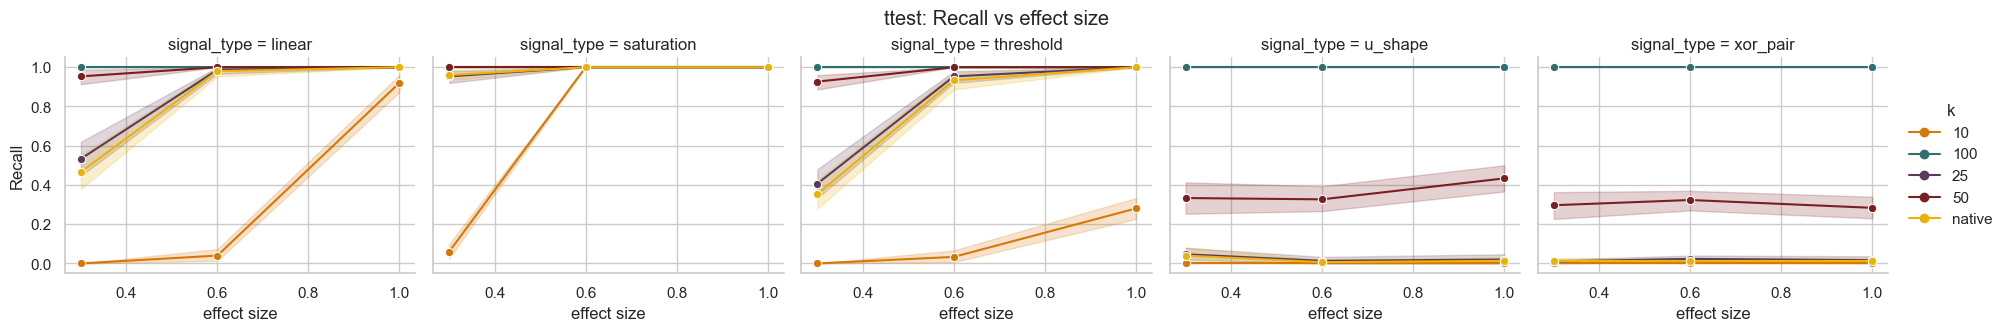

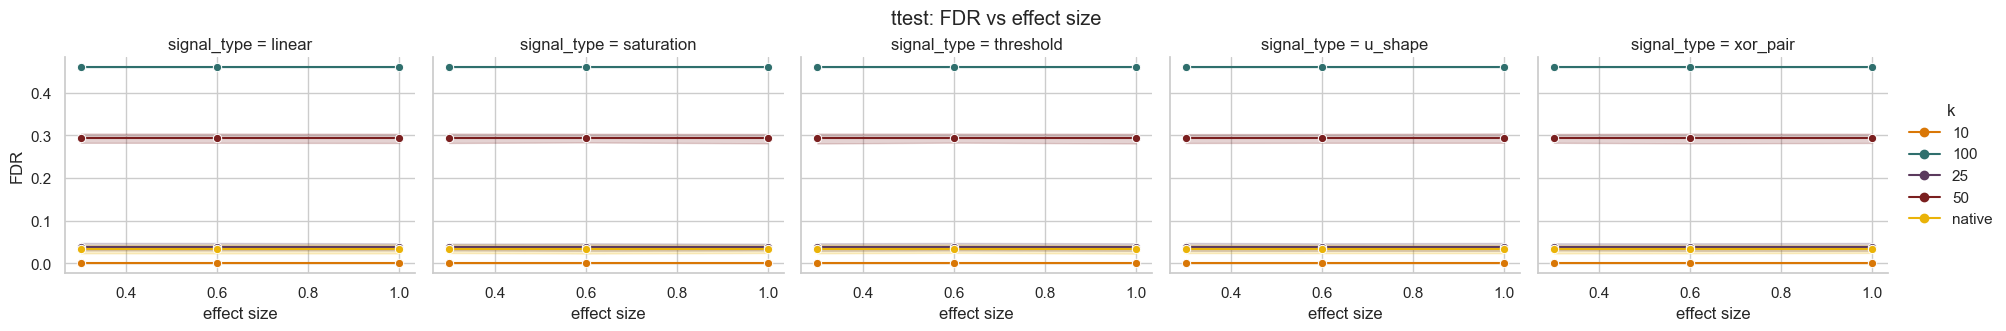

In [58]:
k_values = sorted(sim["k"].unique())
palette_k = dict(zip(k_values, CATEGORICAL[:len(k_values)]))

for metric, ylabel in [("recall", "Recall"), ("fdr", "FDR")]:
    g = sns.relplot(
        data=sim, kind="line",
        x="effect_size", y=metric, hue="k", col="signal_type",
        palette=palette_k, marker="o", errorbar=("ci", 95), height=3.2, aspect=1.2,
        facet_kws={"sharey": True},
    )
    g.set_axis_labels("effect size", ylabel)
    g.fig.suptitle(f"{METHOD}: {ylabel} vs effect size", y=1.03)
    plt.show()

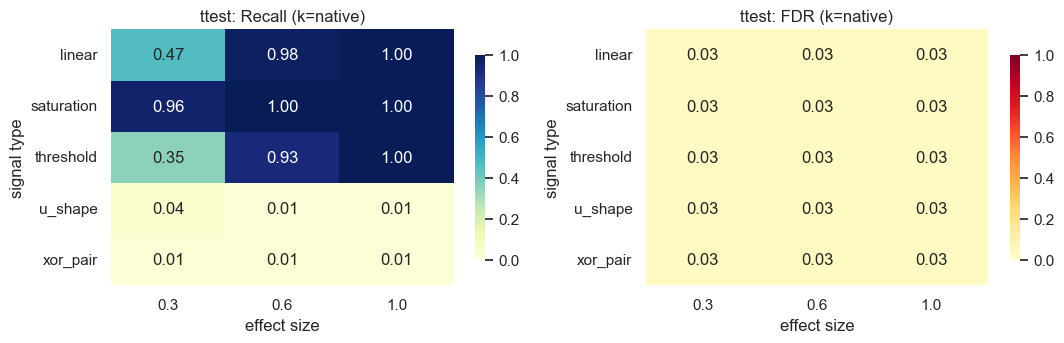

In [59]:
native_k = max(k_values)
sim_native = sim[sim["k"] == native_k]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, metric, cmap, title in [
    (axes[0], "recall", "YlGnBu", f"Recall (k={native_k})"),
    (axes[1], "fdr",    "YlOrRd", f"FDR (k={native_k})"),
]:
    pivot = (sim_native.groupby(["signal_type", "effect_size"])[metric].mean()
             .unstack("effect_size"))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, ax=ax, vmin=0, vmax=1, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{METHOD}: {title}")
    ax.set_xlabel("effect size")
    ax.set_ylabel("signal type")
fig.tight_layout()
plt.show()

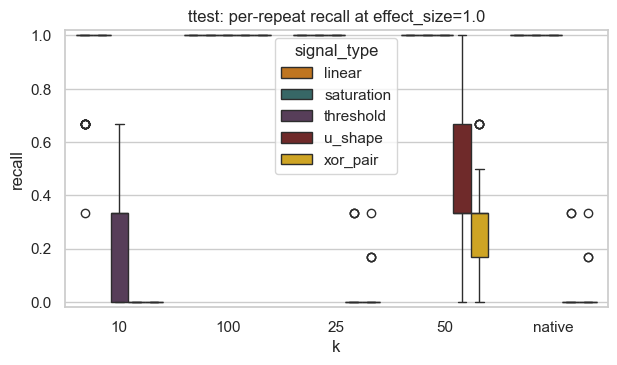

In [60]:
high_effect = sim["effect_size"].max()
sim_top = sim[sim["effect_size"] == high_effect]

fig, ax = plt.subplots(figsize=(7, 3.6))
sns.boxplot(data=sim_top, x="k", y="recall", hue="signal_type",
            palette=CATEGORICAL[:sim_top['signal_type'].nunique()], ax=ax)
ax.set_title(f"{METHOD}: per-repeat recall at effect_size={high_effect}")
ax.set_ylim(-0.02, 1.02)
plt.show()

## 2. Classifier results

Downstream classifier performance when trained on the top-k features selected by this method on each resampled split.

In [61]:
clf = pd.read_parquet(STAGE_DIRS["classifier"] / "scores.parquet")
print(f"{len(clf):,} rows | splits={clf['split_id'].nunique()} | classifiers={sorted(clf['classifier'].unique())} | "
      f"k={sorted(clf['k'].unique())}")
clf.head()

750 rows | splits=50 | classifiers=['LogisticRegression', 'RandomForest', 'XGBoost'] | k=['10', '100', '25', '50', 'native']


,split_id,classifier,k,auc,aupr,n_features_actual
0,0,LogisticRegression,10,0.642140,0.360137,10
1,0,RandomForest,10,0.603122,0.331894,10
2,0,XGBoost,10,0.546265,0.214989,10
3,0,LogisticRegression,25,0.606466,0.353342,25
4,0,RandomForest,25,0.618729,0.337935,25


In [62]:
clf_summary = (
    clf.groupby(["classifier", "k"], as_index=False)
       .agg(auc_mean=("auc", "mean"), auc_std=("auc", "std"),
            aupr_mean=("aupr", "mean"), aupr_std=("aupr", "std"),
            n=("auc", "size"))
       .sort_values(["classifier", "k"])
)
clf_summary.round(3).style.background_gradient(subset=["auc_mean", "aupr_mean"], cmap="YlGnBu")

,classifier,k,auc_mean,auc_std,aupr_mean,aupr_std,n
0,LogisticRegression,10,0.597000,0.086000,0.271000,0.083000,50
1,LogisticRegression,100,0.690000,0.079000,0.336000,0.085000,50
2,LogisticRegression,25,0.634000,0.079000,0.301000,0.080000,50
3,LogisticRegression,50,0.660000,0.080000,0.317000,0.081000,50
4,LogisticRegression,native,0.568000,0.052000,0.237000,0.048000,50
5,RandomForest,10,0.599000,0.085000,0.267000,0.081000,50
6,RandomForest,100,0.670000,0.072000,0.309000,0.074000,50
7,RandomForest,25,0.634000,0.076000,0.291000,0.075000,50
8,RandomForest,50,0.648000,0.077000,0.290000,0.077000,50
9,RandomForest,native,0.569000,0.062000,0.242000,0.063000,50


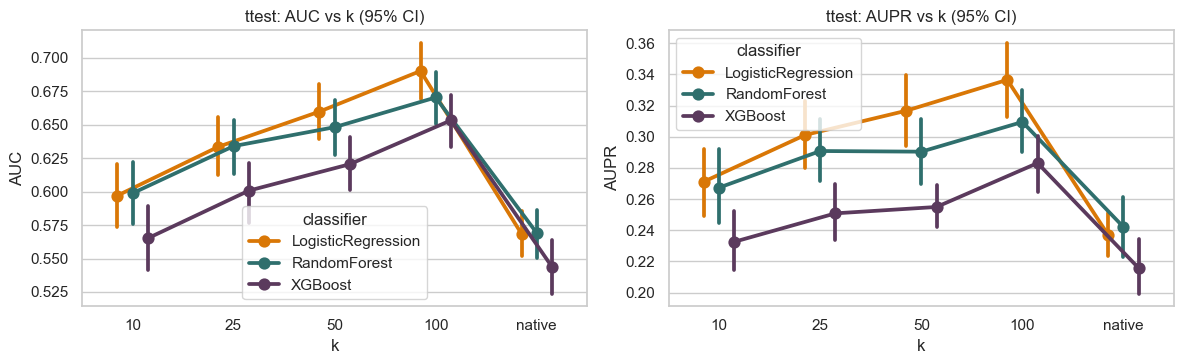

In [63]:
classifier_order = sorted(clf["classifier"].unique())
palette_clf = dict(zip(classifier_order, CATEGORICAL[:len(classifier_order)]))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, metric, ylabel in [(axes[0], "auc", "AUC"), (axes[1], "aupr", "AUPR")]:
    sns.pointplot(data=clf, x="k", y=metric, hue="classifier",
                  palette=palette_clf, errorbar=("ci", 95), dodge=0.3, ax=ax)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{METHOD}: {ylabel} vs k (95% CI)")
fig.tight_layout()
plt.show()

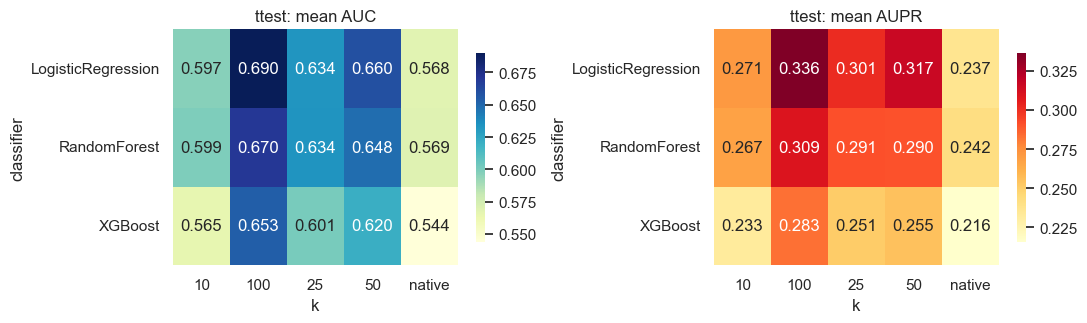

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, metric, cmap, title in [
    (axes[0], "auc",  "YlGnBu", "mean AUC"),
    (axes[1], "aupr", "YlOrRd", "mean AUPR"),
]:
    pivot = clf.groupby(["classifier", "k"])[metric].mean().unstack("k")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{METHOD}: {title}")
fig.tight_layout()
plt.show()

## 3. Stability diagnostics

How often each protein was selected across the resampled splits.
- `stability_significant.parquet` â€” frequency under the significance-threshold rule
- `stability_topk.parquet` â€” frequency for k âˆˆ {10, 25, 50, 100}

At the end of this section we overlay the final protein list (from Section 4) on the stability curves, so you can see whether the final picks came from the stable tail or not.

In [65]:
stab_sig = pd.read_parquet(STAGE_DIRS["selection"] / "stability_significant.parquet")
stab_topk = pd.read_parquet(STAGE_DIRS["selection"] / "stability_topk.parquet")

# Final protein list is defined by full_data_ranking.significant and is used in Section 4 as well.
ranking = pd.read_parquet(STAGE_DIRS["selection"] / "full_data_ranking.parquet")
final_list = ranking[ranking["significant"]].sort_values("rank").reset_index(drop=True)
final_ids = set(final_list["protein_id"])

print(f"significant-rule: {len(stab_sig):,} proteins observed with frequency>0")
print(f"top-k:            {len(stab_topk):,} rows across k={sorted(stab_topk['k'].unique())}")
print(f"final list size:  {len(final_list)} proteins")

significant-rule: 10,776 proteins observed with frequency>0
top-k:            43,104 rows across k=[np.int64(10), np.int64(25), np.int64(50), np.int64(100)]
final list size:  20 proteins


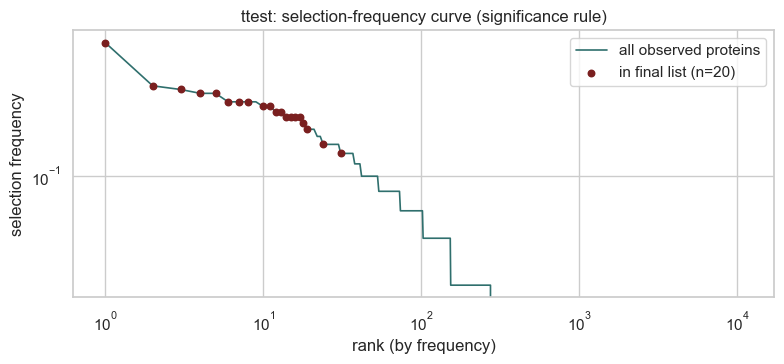

final-list proteins that appear in stability_significant: 20/20


In [66]:
curve = stab_sig.sort_values("frequency", ascending=False).reset_index(drop=True)
curve["rank"] = np.arange(1, len(curve) + 1)
curve["in_final_list"] = curve["protein_id"].isin(final_ids)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(curve["rank"], curve["frequency"], color=PALETTE["secondary"], lw=1.2, label="all observed proteins")
hit = curve[curve["in_final_list"]]
ax.scatter(hit["rank"], hit["frequency"], color=PALETTE["danger"], s=22, zorder=5,
           label=f"in final list (n={len(hit)})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("rank (by frequency)")
ax.set_ylabel("selection frequency")
ax.set_title(f"{METHOD}: selection-frequency curve (significance rule)")
ax.legend()
fig.tight_layout()
plt.show()

n_final_observed = curve["in_final_list"].sum()
print(f"final-list proteins that appear in stability_significant: {n_final_observed}/{len(final_list)}")

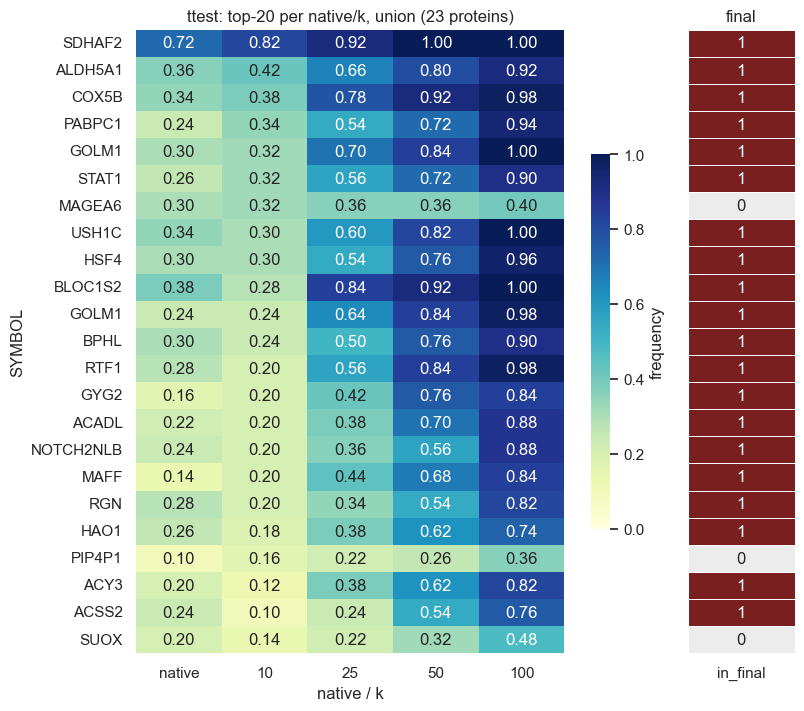

In [81]:
# Top-k/native frequency heatmap: union of the top-20 proteins at each k plus native,
# rows=proteins, cols=[native + k values], cells=frequency, with a final-list membership flag.
topN = 20
k_vals = sorted(stab_topk["k"].unique())
native_col = "native"

def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann_map = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv", usecols=["PROBEID", "SYMBOL"])
ann_map["probe_norm"] = ann_map["PROBEID"].map(_normalize_probe_id)
symbol_lookup = (
    ann_map.dropna(subset=["SYMBOL"])
.drop_duplicates("probe_norm")
.set_index("probe_norm")["SYMBOL"]
)

top_union_k = (
    stab_topk.sort_values(["k", "frequency"], ascending=[True, False])
.groupby("k").head(topN)["protein_id"].tolist()
)
top_union_native = (
    stab_sig.sort_values("frequency", ascending=False)
.head(topN)["protein_id"].tolist()
)
top_union = list(dict.fromkeys(top_union_k + top_union_native))

mat = (stab_topk[stab_topk["protein_id"].isin(top_union)]
.pivot_table(index="protein_id", columns="k", values="frequency", fill_value=0)
.reindex(top_union))
mat[native_col] = mat.index.to_series().map(stab_sig.set_index("protein_id")["frequency"]).fillna(0.0)
mat["in_final"] = mat.index.to_series().isin(final_ids).astype(int)

display_cols = [native_col] + k_vals
row_labels = [symbol_lookup.get(_normalize_probe_id(pid), pid) for pid in mat.index]
mat_display = mat.copy()
mat_display.index = row_labels

fig, (ax_hm, ax_flag) = plt.subplots(
    1, 2, figsize=(1.1 * len(display_cols) + 3, 0.3 * len(mat_display) + 1.2),
    gridspec_kw={"width_ratios": [len(display_cols), 1], "wspace": 0.05},
)
sns.heatmap(
    mat_display[display_cols],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=mat_display[display_cols].values.max(),
    ax=ax_hm,
    cbar_kws={"shrink": 0.6, "label": "frequency"},
)
ax_hm.set_title(f"{METHOD}: top-{topN} per native/k, union ({len(mat_display)} proteins)")
ax_hm.set_xlabel("native / k")
ax_hm.set_ylabel("SYMBOL")

sns.heatmap(
    mat_display[["in_final"]],
    annot=True,
    fmt="d",
    cmap=["#ECECEC", PALETTE["danger"]],
    cbar=False,
    ax=ax_flag,
    linewidths=0.4,
    linecolor="white",
)
ax_flag.set_yticks([])
ax_flag.set_xlabel("")
ax_flag.set_title("final")
plt.show()

In [68]:
thresholds = [0.1, 0.2, 0.3, 0.5]

sig_counts = {f"freq>={t}": int((stab_sig["frequency"] >= t).sum()) for t in thresholds}
topk_counts = (
    stab_topk.groupby("k")
             .apply(lambda g: pd.Series({f"freq>={t}": int((g["frequency"] >= t).sum()) for t in thresholds}))
)
summary = pd.concat(
    [pd.DataFrame([sig_counts], index=["significant"]), topk_counts.rename(lambda k: f"top-{k}")]
)
print("Proteins crossing frequency thresholds:")
display(summary)

print("\nmean_rank / mean_score (significant rule):")
display(stab_sig[["frequency", "mean_rank", "mean_score"]].describe().round(3))

Proteins crossing frequency thresholds:


,freq>=0.1,freq>=0.2,freq>=0.3,freq>=0.5
significant,53,21,9,1
top-10,33,18,9,1
top-25,66,34,21,12
top-50,138,74,48,20
top-100,260,154,107,53



mean_rank / mean_score (significant rule):


,frequency,mean_rank,mean_score
count,10776.000,10776.000,10776.000
mean,0.002,5387.500,0.000
std,0.017,2427.626,0.032
min,0.000,5.740,-0.253
25%,0.000,3445.475,-0.014
50%,0.000,5894.960,-0.001
75%,0.000,7577.125,0.015
max,0.720,9029.040,0.227


## 4. Final protein list and enrichment

The final list is `significant == True` in `full_data_ranking.parquet` â€” i.e. the method's selection when run on the full (non-resampled) cohort. Enrichment below is whatever was produced against that list.

In [69]:
def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv")
ann["probe_norm"] = ann["PROBEID"].map(_normalize_probe_id)

final = final_list.copy()
final["probe_norm"] = final["protein_id"].map(_normalize_probe_id)
final = final.merge(
    ann[["probe_norm", "SYMBOL", "UNIPROT", "GENENAME"]],
    on="probe_norm", how="left",
).drop(columns="probe_norm")

# Join resampling frequency so the reader sees how stable each final protein is.
final = final.merge(
    stab_sig[["protein_id", "frequency"]].rename(columns={"frequency": "resample_freq"}),
    on="protein_id", how="left",
)
final["resample_freq"] = final["resample_freq"].fillna(0.0)

print(f"{len(final)} final proteins | symbols mapped: {final['SYMBOL'].notna().sum()} | "
      f"mean resample frequency: {final['resample_freq'].mean():.3f}")
display(final[["rank", "protein_id", "SYMBOL", "GENENAME", "score", "q_value", "resample_freq"]]
        .round(4)
        .style.background_gradient(subset=["resample_freq"], cmap="YlGnBu"))

20 final proteins | symbols mapped: 20 | mean resample frequency: 0.290


,rank,protein_id,SYMBOL,GENENAME,score,q_value,resample_freq
0,0,seq.26103.20,SDHAF2,succinate dehydrogenase complex assembly factor 2,-0.067900,0.001900,0.720000
1,1,seq.8983.7,GOLM1,golgi membrane protein 1,0.145400,0.015500,0.300000
2,2,seq.17792.158,ALDH5A1,aldehyde dehydrogenase 5 family member A1,-0.116900,0.015500,0.360000
3,3,seq.21184.1,BLOC1S2,biogenesis of lysosomal organelles complex 1 subunit 2,-0.063000,0.015500,0.380000
4,4,seq.7887.57,COX5B,cytochrome c oxidase subunit 5B,-0.043900,0.015500,0.340000
5,5,seq.33451.35,HSF4,heat shock transcription factor 4,-0.043800,0.015500,0.300000
6,6,seq.17725.37,USH1C,USH1 protein network component harmonin,-0.031900,0.015500,0.340000
7,7,seq.7741.111,RTF1,"RTF1 homolog, Paf1/RNA polymerase II complex component",-0.031800,0.015500,0.280000
8,8,seq.17456.53,GOLM1,golgi membrane protein 1,0.156600,0.019200,0.240000
9,9,seq.17813.21,BPHL,biphenyl hydrolase like,-0.115400,0.019200,0.300000


In [70]:
with open(STAGE_DIRS["enrichment"] / "gene_list.json") as f:
    gene_list = json.load(f)

print(f"source: {gene_list['source']}  min_size={gene_list['min_size']}  "
      f"n_proteins={gene_list['n_proteins']}  n_genes={gene_list['n_genes']}")

enrich_proteins = set(gene_list["protein_ids"])
only_final = enrich_proteins ^ set(final["protein_id"])
if only_final:
    print(f"NOTE: {len(only_final)} proteins differ between final list and enrichment input: {sorted(only_final)[:10]}")
else:
    print("Enrichment input matches the final list exactly.")

source: significant  min_size=10  n_proteins=20  n_genes=19
Enrichment input matches the final list exactly.


In [71]:
libraries = sorted(p.name for p in STAGE_DIRS["enrichment"].iterdir() if p.is_dir() and not p.name.startswith("_"))
print("enrichment libraries:", libraries)

rows = []
for lib in libraries:
    bes_path = STAGE_DIRS["enrichment"] / lib / "bes_components.json"
    if not bes_path.exists():
        print(f"[skip] {lib}: bes_components.json missing")
        continue
    bes = load_meta(bes_path)
    rows.append({
        "library": lib,
        "gene_list_size": bes.get("gene_list_size"),
        "background_size": bes.get("background_size"),
        "bes_raw": bes.get("bes_raw"),
        "bes_z":   bes.get("bes_z"),
        "bes_p_emp": bes.get("bes_p_emp"),
        "n_significant_terms": bes.get("bes_components", {}).get("n_significant_terms"),
        "n_terms_input":       bes.get("bes_components", {}).get("n_terms_input"),
    })
bes_df = pd.DataFrame(rows)
bes_df.round(3).style.background_gradient(subset=["bes_z"], cmap="YlGnBu")

enrichment libraries: ['GO_Biological_Process_2025', 'KEGG_2026', 'Reactome_Pathways_2024']


,library,gene_list_size,background_size,bes_raw,bes_z,bes_p_emp,n_significant_terms,n_terms_input
0,GO_Biological_Process_2025,19,9511,1.360000,-0.014000,0.174000,1,212
1,KEGG_2026,19,9511,0.000000,-0.082000,1.000000,0,55
2,Reactome_Pathways_2024,19,9511,0.000000,-0.202000,1.000000,0,144


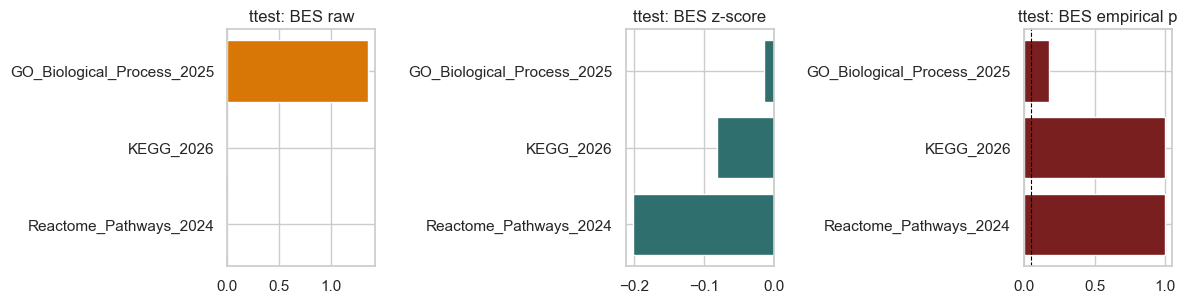

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (metric, color, title) in zip(axes, [
    ("bes_raw", PALETTE["primary"],  "BES raw"),
    ("bes_z",   PALETTE["secondary"], "BES z-score"),
    ("bes_p_emp", PALETTE["danger"], "BES empirical p"),
]):
    ax.barh(bes_df["library"], bes_df[metric], color=color)
    ax.set_title(f"{METHOD}: {title}")
    ax.invert_yaxis()
axes[2].axvline(0.05, color="black", ls="--", lw=0.8)
fig.tight_layout()
plt.show()

In [73]:
TOP_N_TERMS = 15
for lib in libraries:
    terms = pd.read_parquet(STAGE_DIRS["enrichment"] / lib / "terms.parquet")
    sig = terms[terms["q_value"] < 0.05].sort_values("q_value")
    print(f"\n### {lib}:  {len(sig)} terms q<0.05 (of {len(terms)})")
    show = (sig if len(sig) else terms.sort_values("q_value")).head(TOP_N_TERMS)
    display(show[["term", "q_value", "p_value", "overlap_size", "term_size", "genes"]].round(4))


### GO_Biological_Process_2025:  1 terms q<0.05 (of 212)


,term,q_value,p_value,overlap_size,term_size,genes
0,Primary Alcohol Catabolic Process (GO:0034310),0.0436,0.0002,2,2,ACSS2;HAO1



### KEGG_2026:  0 terms q<0.05 (of 55)


,term,q_value,p_value,overlap_size,term_size,genes
0,GLYOXYLATE AND DICARBOXYLATE METABOLISM,0.0559,0.0010,2,2,ACSS2;HAO1
1,BUTANOATE METABOLISM,0.2886,0.0276,1,1,ALDH5A1
2,ASCORBATE AND ALDARATE METABOLISM,0.2886,0.0412,1,1,RGN
3,PENTOSE PHOSPHATE PATHWAY,0.2886,0.0412,1,1,RGN
4,PROPANOATE METABOLISM,0.2886,0.0412,1,1,ACSS2
5,STARCH AND SUCROSE METABOLISM,0.2886,0.0412,1,1,GYG2
6,FATTY ACID DEGRADATION,0.2886,0.0507,1,1,ACADL
7,"ALANINE, ASPARTATE AND GLUTAMATE METABOLISM",0.2886,0.0545,1,1,ALDH5A1
8,PYRUVATE METABOLISM,0.2886,0.0696,1,1,ACSS2
9,CARDIAC MUSCLE CONTRACTION,0.2886,0.0770,1,1,COX5B



### Reactome_Pathways_2024:  0 terms q<0.05 (of 144)


,term,q_value,p_value,overlap_size,term_size,genes
0,Metabolism,0.1353,0.0026,8,8,ACY3;ACSS2;SDHAF2;ACADL;HAO1;COX5B;GYG2;BPHL
1,Biological Oxidations,0.1353,0.0036,3,3,ACY3;ACSS2;BPHL
2,Beta Oxidation of lauroyl-CoA to decanoyl-CoA-CoA,0.1353,0.0060,1,1,ACADL
3,Mitochondrial Fatty Acid Beta-Oxidation of Uns...,0.1353,0.0080,1,1,ACADL
4,Phase I - Functionalization of Compounds,0.1353,0.0091,2,2,ACSS2;BPHL
5,Glycogen Storage Diseases,0.1353,0.0139,1,1,GYG2
6,Mitochondrial Fatty Acid Beta-Oxidation of Sat...,0.1353,0.0139,1,1,ACADL
7,Glycogen Synthesis,0.1353,0.0159,1,1,GYG2
8,Interleukin-9 Signaling,0.1353,0.0159,1,1,STAT1
9,Glycogen Breakdown (Glycogenolysis),0.1353,0.0178,1,1,GYG2
